# Benchmarking with igraph

This notebook is an example of benchmarking community detection algorithms using ABCD with igraph.

In [1]:
from time import perf_counter

import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import partition_igraph  # noqa: F401
from sklearn.metrics import adjusted_rand_score as ari
from tqdm import tqdm

from abcd_graph import ABCD

In [2]:
algs = [
    "community_multilevel",
    "community_leiden",
    "community_ecg",
    "community_label_propagation",
    "community_infomap",
    "community_walktrap",
]

## Performance

First lets test how well each algorithms can detect the ground truth communities subject to increasing amount of noise in the graph. To evaluate the similarity between the ground truth partition, we'll use the adjusted rand index (ARI) and a graph aware adjustment (GARI).

In [3]:
n = 5000
xis = np.linspace(0.1, 0.7, 13)
reps = 10

aris = np.empty((len(algs), len(xis), reps))
garis = np.empty_like(aris)

abcd = ABCD(n)

with tqdm(total=len(xis) * reps * len(algs)) as pbar:
    for j, xi in enumerate(xis):
        abcd.xi = xi
        for k in range(reps):
            sample = abcd.sample()
            sample_graph = sample.to_igraph()
            sample_coms = sample.community_array

            for i, alg in enumerate(algs):
                predict = getattr(sample_graph, alg)()
                if isinstance(predict, ig.VertexDendrogram):
                    predict = predict.as_clustering()
                aris[i, j, k] = ari(sample_coms, predict.membership)
                garis[i, j, k] = sample_graph.gam(
                    ig.VertexClustering(sample_graph, sample_coms), predict
                )
                pbar.update()

100%|██████████| 780/780 [06:07<00:00,  2.12it/s]


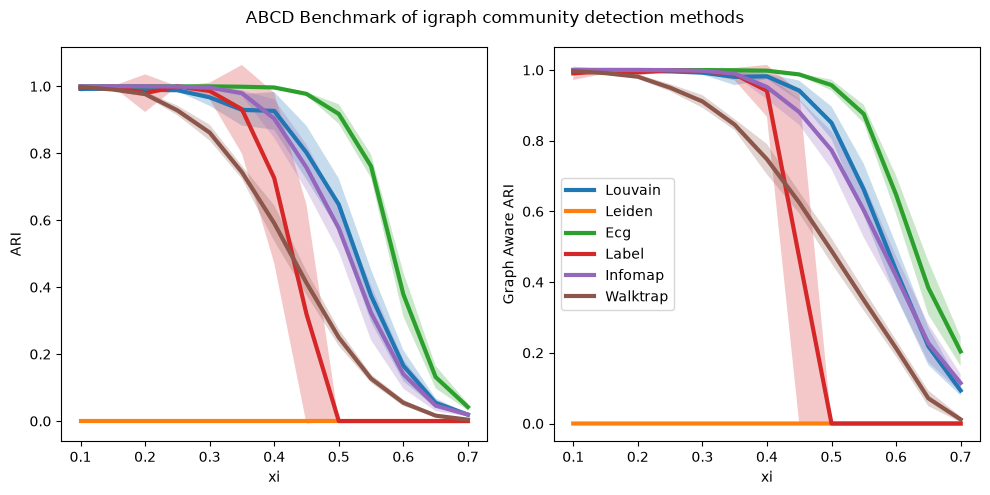

In [4]:
ari_means = np.mean(aris, axis=2)
ari_stds = np.std(aris, axis=2)
gari_means = np.mean(garis, axis=2)
gari_stds = np.std(garis, axis=2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for i, alg in enumerate(algs):
    name = alg.split("_")[1]
    if name == "multilevel":
        name = "louvain"

    axs[0].plot(xis, ari_means[i], lw=3, label=name.capitalize())
    axs[0].fill_between(
        xis, ari_means[i] - ari_stds[i], ari_means[i] + ari_stds[i], alpha=0.25
    )

    axs[1].plot(xis, gari_means[i], lw=3, label=name.capitalize())
    axs[1].fill_between(
        xis, gari_means[i] - gari_stds[i], gari_means[i] + gari_stds[i], alpha=0.25
    )
axs[1].legend()

axs[0].set_xlabel("xi")
axs[0].set_ylabel("ARI")

axs[1].set_ylabel("Graph Aware ARI")
axs[1].set_xlabel("xi")

fig.suptitle("ABCD Benchmark of igraph community detection methods")
fig.tight_layout()

Looks like ECG is doing the best, while Leiden is doing terrible. That's a bit strange since Leiden is usualy at least as good as Louvain (it is an extension after all), but we note that the igraph implementation of Leiden defaults to the `constant potts model` objective instead of the more traditional `modularity`.

Let's also note that the shaded region of the label propagation algorithms extends above 1 for xi around 0.4. This is just the result of a very large standard deviation, as both ARI and GARI are capped at 1.

## Time

We can also use ABCD to test how each algorithm scales.

In [5]:
ns = np.linspace(1000, 10000, 10, dtype="int64")
reps = 10

times = np.empty((len(algs), len(ns), reps))

abcd = ABCD(1000)

with tqdm(total=len(ns) * reps * len(algs)) as pbar:
    for j, n in enumerate(ns):
        abcd.n = n
        for k in range(reps):
            sample = abcd.sample()
            sample_graph = sample.to_igraph()
            sample_coms = sample.community_array

            for i, alg in enumerate(algs):
                start = perf_counter()
                predict = getattr(sample_graph, alg)()
                end = perf_counter()
                times[i, j, k] = end - start
                pbar.update()

100%|██████████| 600/600 [04:33<00:00,  2.19it/s]


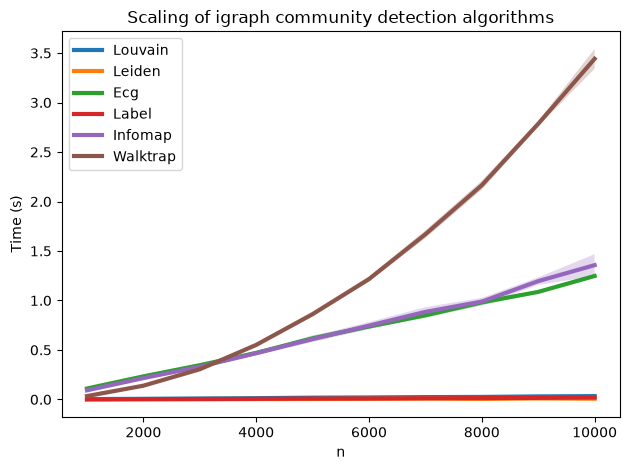

In [6]:
time_means = np.mean(times, axis=2)
time_stds = np.std(times, axis=2)

for i, alg in enumerate(algs):
    name = alg.split("_")[1]
    if name == "multilevel":
        name = "louvain"
    plt.plot(ns, time_means[i], lw=3, label=name.capitalize())
    plt.fill_between(
        ns, time_means[i] - time_stds[i], time_means[i] + time_stds[i], alpha=0.25
    )

plt.legend()
plt.title("Scaling of igraph community detection algorithms")
plt.xlabel("n")
plt.ylabel("Time (s)")
plt.tight_layout()

Looks like everything except Walktrap scales linearly. Let's zoom in on Louvain, Leiden and Label to make sure.

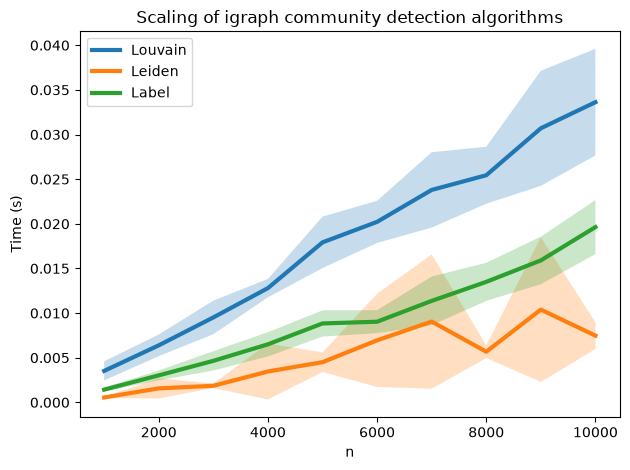

In [7]:
time_means = np.mean(times, axis=2)
time_stds = np.std(times, axis=2)

for i, alg in enumerate(algs):
    name = alg.split("_")[1]
    if name == "multilevel":
        name = "louvain"
    if name in ["louvain", "leiden", "label"]:
        plt.plot(ns, time_means[i], lw=3, label=name.capitalize())
        plt.fill_between(
            ns, time_means[i] - time_stds[i], time_means[i] + time_stds[i], alpha=0.25
        )

plt.legend()
plt.title("Scaling of igraph community detection algorithms")
plt.xlabel("n")
plt.ylabel("Time (s)")
plt.tight_layout()

## References

Louvain
- [Vincent D Blondel, Jean-Loup Guillaume, Renaud Lambiotte and Etienne Lefebvre. Fast unfolding of communities in large networks. Journal of Statistical Mechanics: Theory and Experiment, P10008 (2008) doi: 10.1088/1742-5468/2008/10/P10008](https://doi.org/10.1088/1742-5468/2008/10/P10008)

Leiden
- [V. A. Traag, L. Waltman & N. J. van Eck. From Louvain to Leiden: guaranteeing well-connected communities. Scientific Reports, 9:5233 (2019) doi: 10.1038/s41598-019-41695-z](https://doi.org/10.1038/s41598-019-41695-z)

ECG
- [Valérie Poulin & François Théberge. Ensemble clustering for graphs: comparisons and applications. Applied Network Science, 4:51 (2019) doi: 10.1007/s41109-019-0162-z](https://doi.org/10.1007/s41109-019-0162-z)

Label Propagation
- [Usha Nandini Raghavan, Réka Albert, and Soundar Kumara. Near linear time algorithm to detect community structures in large-scale networks. Physical Review E, 76:036106 (2007) doi: 10.1103/PhysRevE.76.036106](https://doi.org/10.1103/PhysRevE.76.036106)

Infomap
- [Martin Rosvall and Carl T. Bergstrom. Maps of information flow reveal community structure in complex networks, Proceedings of the National Academy of Sciences, 105(4):1118-1123 (2008) doi: 10.1073/pnas.0706851105](https://doi.org/10.1073/pnas.0706851105)

Walktrap
- [Pascal Pons and Matthieu Latapy. Computing Communities in Large Networks Using Random Walks. International Symposium on Computer and Information Sciences, Lecture Notes in Computer Science, 3733:284–293 (2005) doi: 10.1007/11569596_31](https://doi.org/10.1007/11569596_31)

ARI
- [Lawrence Hubert and Phipps Arabie. Comparing partitions.  Journal of Classification , 2:193–218 (1985) doi: 10.1007/BF01908075](https://doi.org/10.1007/BF01908075)

Graph Aware ARI
- [Valérie Poulin and François Théberge. Comparing Graph Clusterings: Set Partition Measures vs. Graph-Aware Measures. IEEE Transactions on Pattern Analysis and Machine Intelligence, 43(6):2127 - 2132 (2021) doi: 10.1109/TPAMI.2020.3009862](https://doi.org/10.1109/TPAMI.2020.3009862)
